# Canonical Task Grouping via Semantic Clustering

Pools all `task_canonical` labels from both manually-reviewed streams,
embeds them with a sentence-transformer model, clusters by cosine similarity,
and assigns a single **canonical group name** to each cluster.

The resulting groups are used to re-derive which tasks are **shared** between
the SLM and LLM streams without relying on exact string matching.

| Input | File |
|---|---|
| Stream 1 (SLM) | `slm_shared_tasks_checked.csv` |
| Stream 2 (LLM) | `llm_shared_tasks_checked.csv` |

| Output | File |
|---|---|
| Canonical label map | `canonical_label_map.csv` |
| Overlap summary | `overlap_task_summary.csv` |

In [14]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sentence_transformers import SentenceTransformer

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

TASK_DIR = Path('.')
SLM_CSV  = TASK_DIR / 'slm_shared_tasks_checked.csv'
LLM_CSV  = TASK_DIR / 'llm_shared_tasks_checked.csv'

STREAM_COLORS  = {'small_local': '#4A90D9', 'large_general': '#E67E22'}
STREAM_LABELS  = {'small_local': 'Stream 1 (SLM)', 'large_general': 'Stream 2 (LLM)'}

# ── clustering threshold (cosine distance) ────────────────────────────────
# Lower  → fewer, broader groups.  Higher → more, narrower groups.
# Recommended range: 0.45 – 0.55
CLUSTER_THRESHOLD = 0.52

print('All imports OK')
print('SLM file:', SLM_CSV.exists())
print('LLM file:', LLM_CSV.exists())

All imports OK
SLM file: True
LLM file: True


## 1 · Load data & fix obvious label errors

In [15]:
# ── labels to drop entirely (noise / data-entry errors) ──────────────────
DROP_LABELS = {
    # theme name accidentally used as a task label
    'information',
    # raw story text pasted by accident
    'with notes on where i want things in the story to be in regards to the plot',
    ' with notes on where i want things in the story to be in regards to the plot',
}

# ── typo / truncation fixes applied BEFORE clustering ────────────────────
# Maps lower-cased raw label → corrected canonical label
FIXMAP = {
    'fine-tunin':          'fine-tuning',
    'data analysis':       'analyze data',
    'analyze video':       'video analysis',
    'analyze workflow':    'workflow analysis',
    'analyze business data': 'business data analysis',
}

def load_and_fix(path: Path, stream_val: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df['stream'] = stream_val
    df['date']   = pd.to_datetime(df['date'], errors='coerce')
    df = df.drop(columns=[c for c in ['manual_label','manual_notes'] if c in df.columns])
    # apply fixes to task_canonical
    df['task_canonical'] = df['task_canonical'].apply(
        lambda x: FIXMAP.get(str(x).strip().lower(), str(x).strip())
                  if pd.notna(x) else x
    )
    # drop noise rows
    mask_drop = df['task_canonical'].str.strip().str.lower().isin(DROP_LABELS)
    dropped = mask_drop.sum()
    df = df[~mask_drop].copy()
    if dropped:
        print(f'  {stream_val}: dropped {dropped} noise rows')
    return df

slm = load_and_fix(SLM_CSV, 'small_local')
llm = load_and_fix(LLM_CSV, 'large_general')
df  = pd.concat([slm, llm], ignore_index=True)

print(f'\nSLM records : {len(slm):,}')
print(f'LLM records : {len(llm):,}')
print(f'Total       : {len(df):,}')
print(f'NaN task_canonical: {df["task_canonical"].isna().sum()}')

  large_general: dropped 2 noise rows

SLM records : 104
LLM records : 102
Total       : 206
NaN task_canonical: 2


## 2 · Semantic embedding & clustering

In [16]:
# ── collect all unique labels ─────────────────────────────────────────────
all_labels = sorted(df['task_canonical'].dropna().unique())
print(f'Unique task_canonical labels: {len(all_labels)}')
print(all_labels)

# ── embed with sentence-transformers ─────────────────────────────────────
encoder    = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = encoder.encode(all_labels, show_progress_bar=True, normalize_embeddings=True)

sim_matrix  = cosine_similarity(embeddings)
dist_matrix = np.clip(1 - sim_matrix, 0, None)

print(f'\nEmbedding matrix: {embeddings.shape}')

Unique task_canonical labels: 39
['RAG', 'agent workflow', 'analyze data', 'brainstorming', 'build apps', 'business data analysis', 'conduct deep research', 'conversational chat', 'create documents', 'create web app', 'creative writing', 'debugging', 'drafting emails', 'email management', 'fine-tuning', 'format text', 'generate audio', 'generate content', 'generate diagrams', 'generate images', 'generate story ideas', 'improve text', 'knowledge base', 'manage tasks', 'planning / scheduling', 'proofreading', 'question answering', 'scripting', 'search the database', 'search the web', 'set reminders', 'suggestion', 'summarization', 'take notes', 'task automation', 'transcription', 'translation', 'video analysis', 'workflow analysis']


Batches: 100%|██████████| 2/2 [00:00<00:00, 412.12it/s]


Embedding matrix: (39, 384)


In [17]:
# ── agglomerative clustering on cosine distance ───────────────────────────
clustering = AgglomerativeClustering(
    n_clusters=None,
    metric='precomputed',
    linkage='average',
    distance_threshold=CLUSTER_THRESHOLD,
)
clustering.fit(dist_matrix)

label_df = pd.DataFrame({'label': all_labels, 'cluster_id': clustering.labels_})
print(f'Clusters formed: {clustering.n_clusters_}  (threshold={CLUSTER_THRESHOLD})')

# ── for each cluster, pick the most frequent label in the full dataset ────
label_counts = df['task_canonical'].value_counts()

canonical_map = {}   # raw label → canonical group name
cluster_info  = []   # one row per cluster

for cid in sorted(label_df['cluster_id'].unique()):
    members = label_df[label_df['cluster_id'] == cid]['label'].tolist()
    # canonical name = member with highest mention count (tie → alphabetical)
    canon = max(members, key=lambda l: (label_counts.get(l, 0), l))
    for m in members:
        canonical_map[m] = canon
    # which streams are represented?
    rows_in_cluster = df[df['task_canonical'].isin(members)]
    streams_present = set(rows_in_cluster['stream'].unique())
    slm_cnt = (rows_in_cluster['stream'] == 'small_local').sum()
    llm_cnt = (rows_in_cluster['stream'] == 'large_general').sum()
    overlap = ('shared'   if streams_present == {'small_local','large_general'}
               else 'SLM only' if 'small_local' in streams_present
               else 'LLM only')
    # intra-cluster avg similarity
    idxs = [all_labels.index(m) for m in members]
    if len(idxs) > 1:
        pairs = [(i,j) for i in idxs for j in idxs if i < j]
        avg_sim = np.mean([sim_matrix[i,j] for i,j in pairs])
    else:
        avg_sim = 1.0
    cluster_info.append({'canonical': canon, 'members': '|'.join(sorted(members)),
                         'n_members': len(members), 'avg_sim': round(avg_sim, 3),
                         'slm_mentions': slm_cnt, 'llm_mentions': llm_cnt,
                         'total': slm_cnt + llm_cnt, 'overlap': overlap})

cluster_df = pd.DataFrame(cluster_info).sort_values('total', ascending=False).reset_index(drop=True)

# map every record to its canonical group
df['canonical_group'] = df['task_canonical'].map(canonical_map)
slm['canonical_group'] = slm['task_canonical'].map(canonical_map)
llm['canonical_group'] = llm['task_canonical'].map(canonical_map)

print(f'\nCluster summary ({len(cluster_df)} groups):')
print(cluster_df[['canonical','members','avg_sim','slm_mentions','llm_mentions','overlap']].to_string(index=False))

Clusters formed: 29  (threshold=0.52)

Cluster summary (29 groups):
            canonical                               members  avg_sim  slm_mentions  llm_mentions  overlap
     creative writing creative writing|generate story ideas    0.559            18            21   shared
        summarization                         summarization    1.000            18            11   shared
            scripting                             scripting    1.000             8            12   shared
      task automation          manage tasks|task automation    0.604             8            11   shared
        brainstorming              brainstorming|suggestion    0.513             4            11   shared
        transcription                         transcription    1.000            11             2   shared
          translation                           translation    1.000             5             3   shared
         analyze data   analyze data|business data analysis    0.652             2  

## 3 · Similarity heatmap across all labels

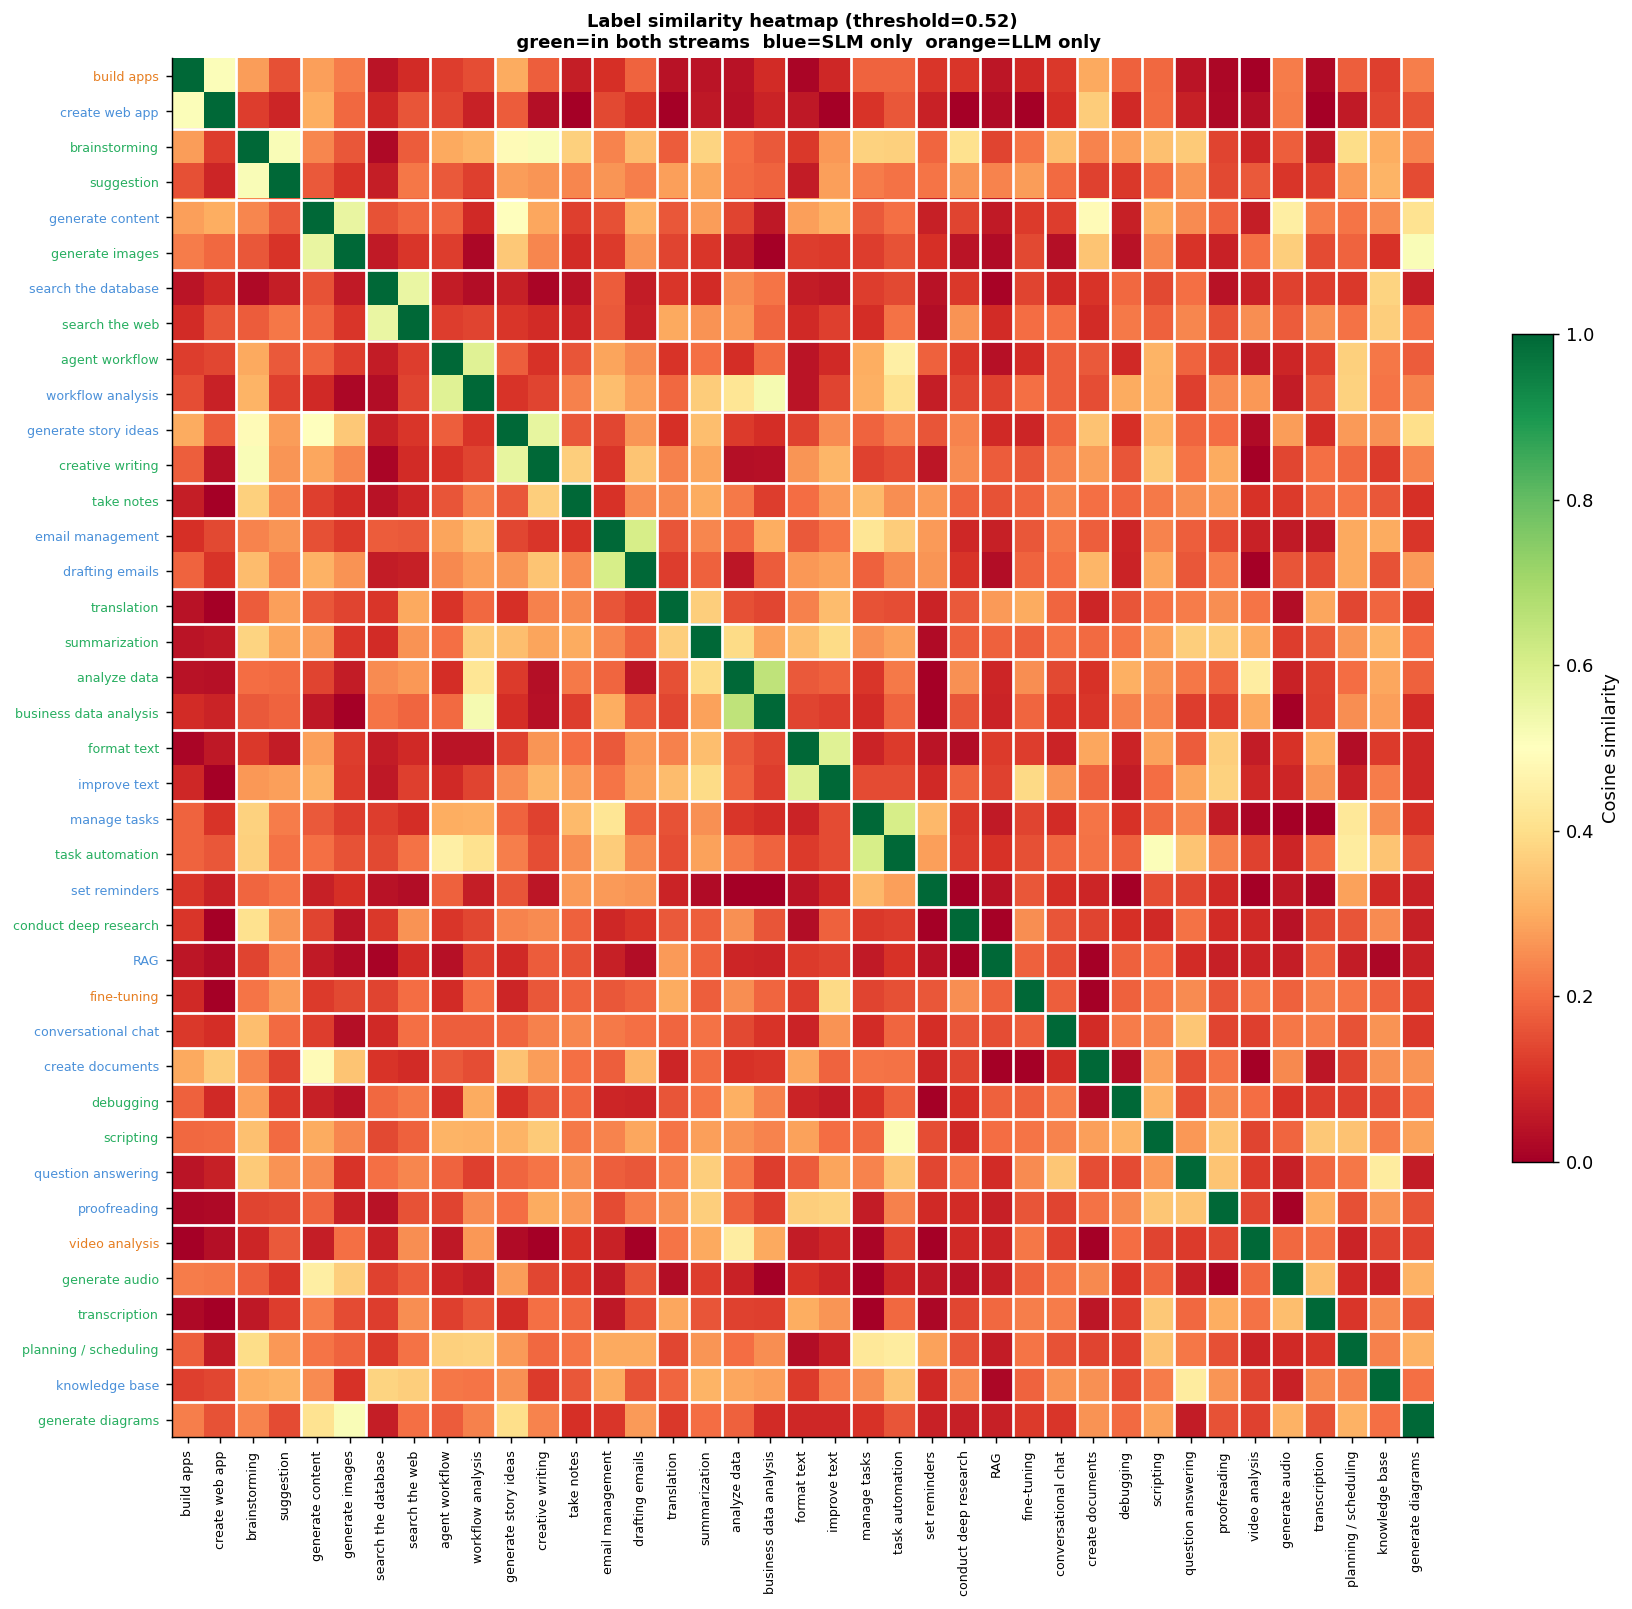

In [18]:
# sort labels by cluster so clustered labels sit together
sort_order = label_df.sort_values('cluster_id')['label'].tolist()
idx        = [all_labels.index(l) for l in sort_order]
sim_sorted = sim_matrix[np.ix_(idx, idx)]

# colour-code y-axis labels: blue=SLM-only, orange=LLM-only, green=in-both
tasks_slm_set = set(slm['task_canonical'].dropna().unique())
tasks_llm_set = set(llm['task_canonical'].dropna().unique())
def label_color(lbl):
    in_s = lbl in tasks_slm_set
    in_l = lbl in tasks_llm_set
    if in_s and in_l: return '#27AE60'
    if in_s:          return '#4A90D9'
    return '#E67E22'

n = len(sort_order)
fig, ax = plt.subplots(figsize=(max(10, n*0.35), max(8, n*0.32)))
im = ax.imshow(sim_sorted, cmap='RdYlGn', vmin=0.0, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='Cosine similarity', shrink=0.6)
ax.set_xticks(range(n))
ax.set_xticklabels(sort_order, rotation=90, fontsize=7)
ax.set_yticks(range(n))
yticklabels = ax.set_yticklabels(sort_order, fontsize=7)
for tick, lbl in zip(yticklabels, sort_order):
    tick.set_color(label_color(lbl))

# draw cluster boundaries
cids = label_df.set_index('label').loc[sort_order, 'cluster_id'].tolist()
boundary_pos = [i+0.5 for i in range(n-1) if cids[i] != cids[i+1]]
for pos in boundary_pos:
    ax.axhline(pos, color='white', linewidth=1.5)
    ax.axvline(pos, color='white', linewidth=1.5)

ax.set_title(f'Label similarity heatmap (threshold={CLUSTER_THRESHOLD})\n'
             f'  green=in both streams  blue=SLM only  orange=LLM only',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Canonical groups — shared vs stream-only

In [19]:
shared_groups  = cluster_df[cluster_df['overlap'] == 'shared']
slm_only       = cluster_df[cluster_df['overlap'] == 'SLM only']
llm_only       = cluster_df[cluster_df['overlap'] == 'LLM only']

print(f'Total canonical groups : {len(cluster_df)}')
print(f'  Shared (both streams): {len(shared_groups)}')
print(f'  SLM only             : {len(slm_only)}')
print(f'  LLM only             : {len(llm_only)}')
print(f'\nSLM records covered   : {cluster_df["slm_mentions"].sum()} / {len(slm)}')
print(f'LLM records covered   : {cluster_df["llm_mentions"].sum()} / {len(llm)}')

print(f'\n── Shared clustered groups ──────────────────────────────────')
for _, row in shared_groups.iterrows():
    members = row['members'].split('|')
    sim_str = f'sim={row["avg_sim"]:.2f}' if len(members) > 1 else 'single'
    print(f'  {row["canonical"]:<35s}  SLM={row["slm_mentions"]:3d}  '
          f'LLM={row["llm_mentions"]:3d}  [{sim_str}]  members: {members}')

Total canonical groups : 29
  Shared (both streams): 19
  SLM only             : 8
  LLM only             : 2

SLM records covered   : 104 / 104
LLM records covered   : 100 / 102

── Shared clustered groups ──────────────────────────────────
  creative writing                     SLM= 18  LLM= 21  [sim=0.56]  members: ['creative writing', 'generate story ideas']
  summarization                        SLM= 18  LLM= 11  [single]  members: ['summarization']
  scripting                            SLM=  8  LLM= 12  [single]  members: ['scripting']
  task automation                      SLM=  8  LLM= 11  [sim=0.60]  members: ['manage tasks', 'task automation']
  brainstorming                        SLM=  4  LLM= 11  [sim=0.51]  members: ['brainstorming', 'suggestion']
  transcription                        SLM= 11  LLM=  2  [single]  members: ['transcription']
  translation                          SLM=  5  LLM=  3  [single]  members: ['translation']
  analyze data                         SL

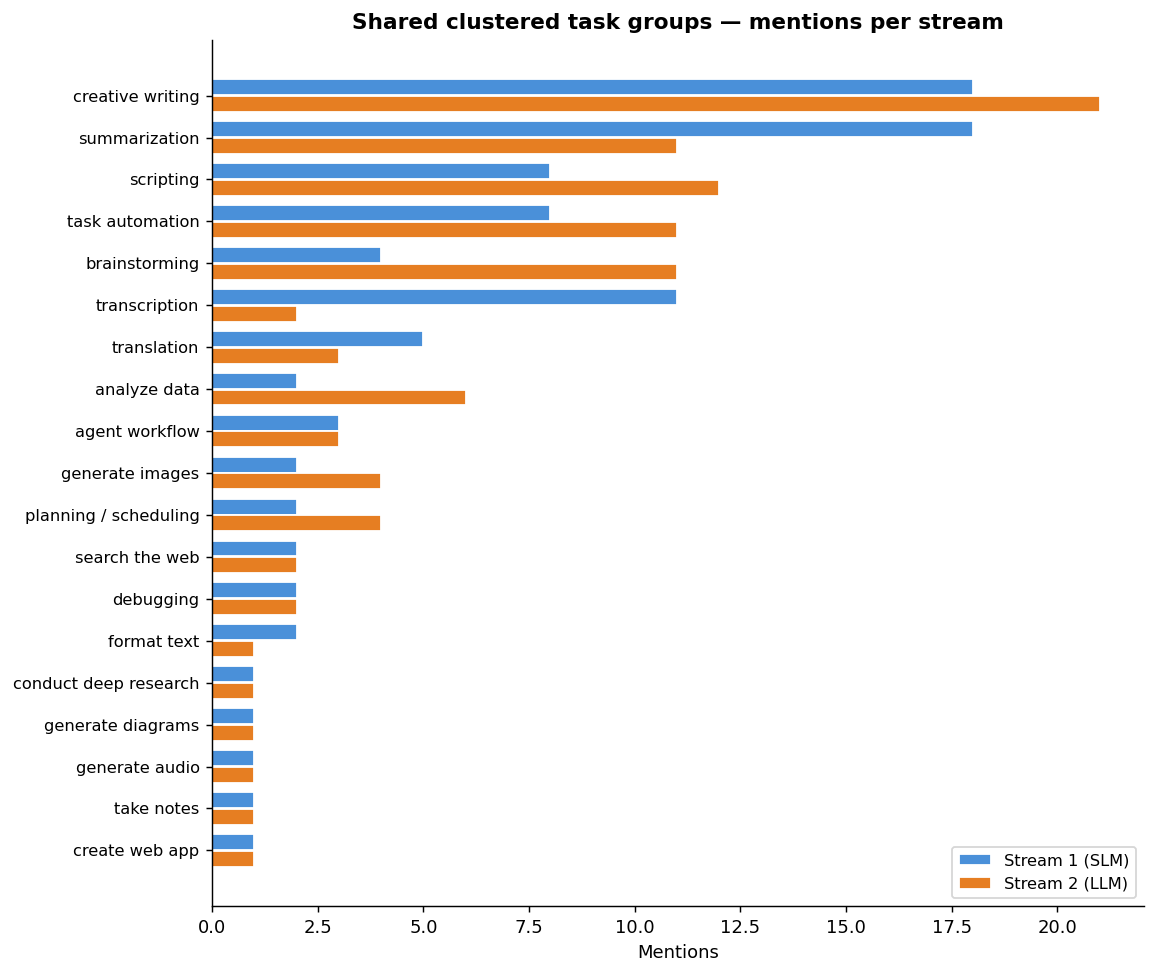

In [20]:
# ── side-by-side bar chart for shared canonical groups ───────────────────
shared_sorted = shared_groups.sort_values('total', ascending=True)
y = range(len(shared_sorted))

fig, ax = plt.subplots(figsize=(9, max(5, len(shared_sorted)*0.4)))
ax.barh([i + 0.2 for i in y], shared_sorted['slm_mentions'].values, height=0.38,
        color=STREAM_COLORS['small_local'],   label='Stream 1 (SLM)', edgecolor='white')
ax.barh([i - 0.2 for i in y], shared_sorted['llm_mentions'].values, height=0.38,
        color=STREAM_COLORS['large_general'], label='Stream 2 (LLM)', edgecolor='white')
ax.set_yticks(list(y))
ax.set_yticklabels(shared_sorted['canonical'].values, fontsize=9)
ax.set_xlabel('Mentions')
ax.set_title('Shared clustered task groups — mentions per stream',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5 · All canonical groups ranked by total mentions

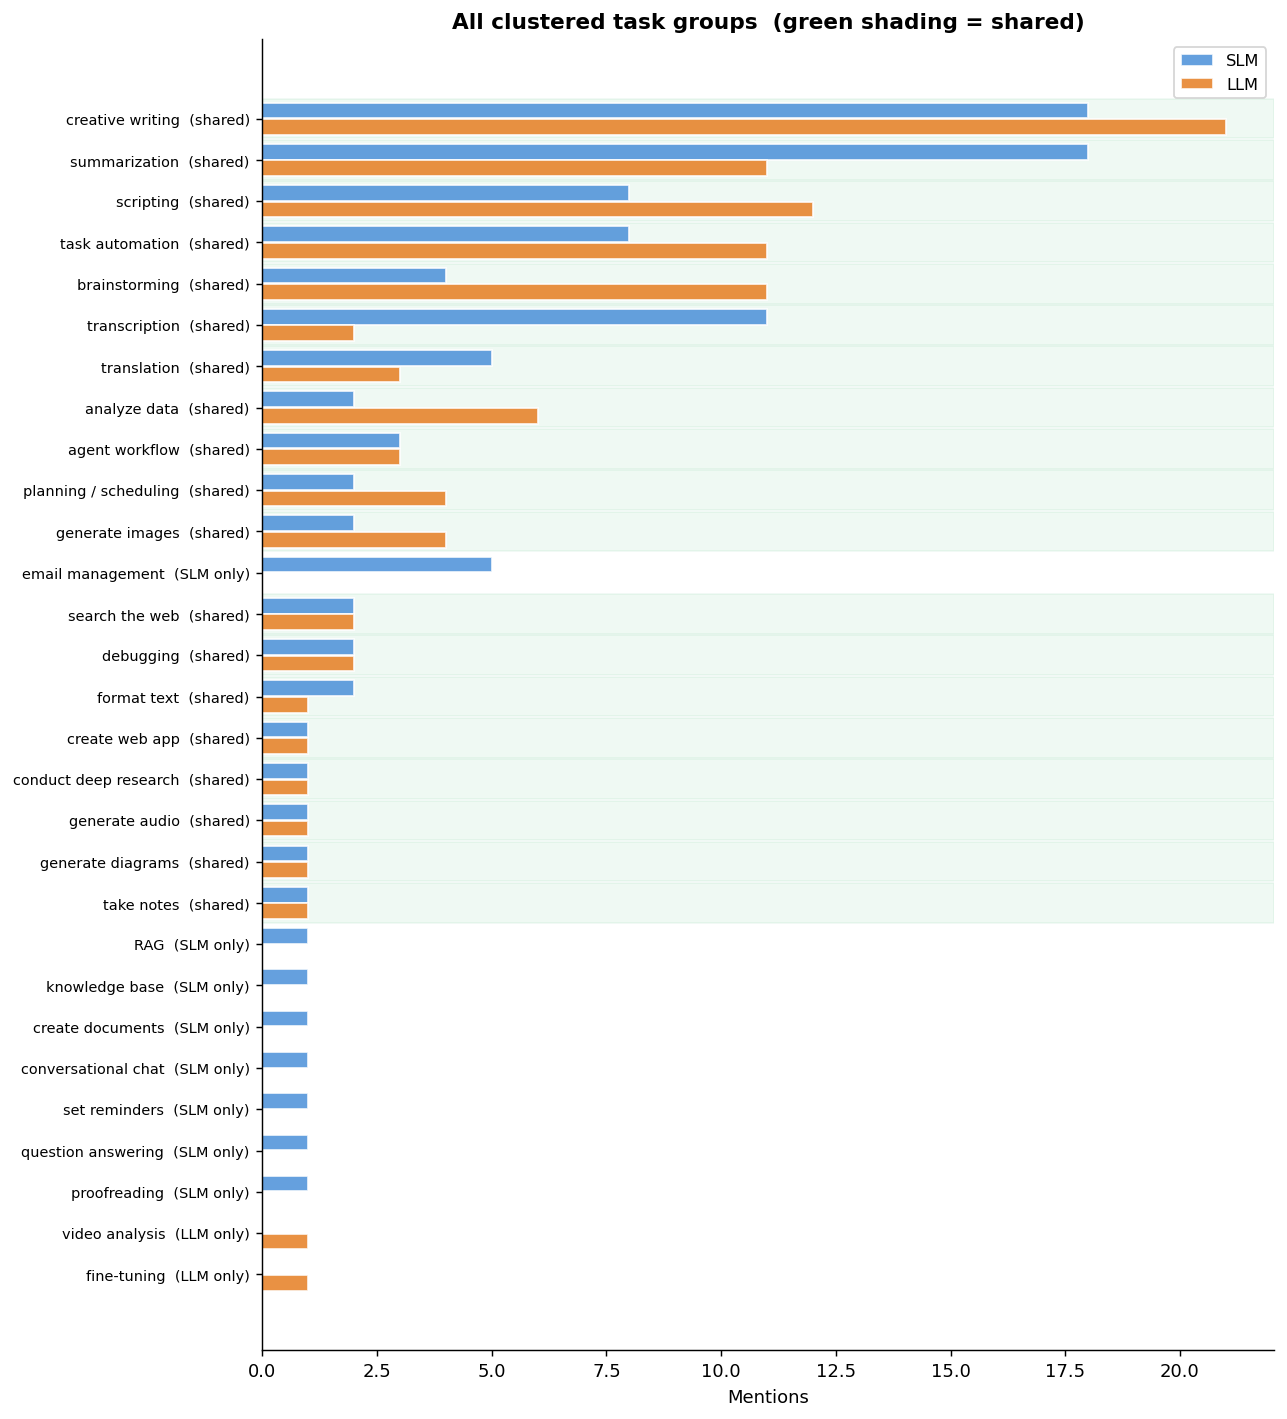

In [21]:
fig, ax = plt.subplots(figsize=(10, max(6, len(cluster_df)*0.38)))

ranked = cluster_df.sort_values('total', ascending=True)
y      = range(len(ranked))
colors = {'shared':   '#27AE60',
          'SLM only': STREAM_COLORS['small_local'],
          'LLM only': STREAM_COLORS['large_general']}

ax.barh([i + 0.2 for i in y], ranked['slm_mentions'].values, height=0.38,
        color=STREAM_COLORS['small_local'],   label='SLM', edgecolor='white', alpha=0.85)
ax.barh([i - 0.2 for i in y], ranked['llm_mentions'].values, height=0.38,
        color=STREAM_COLORS['large_general'], label='LLM', edgecolor='white', alpha=0.85)

# shade shared groups
for i, (_, row) in enumerate(ranked.iterrows()):
    if row['overlap'] == 'shared':
        ax.axhspan(i - 0.48, i + 0.48, color='#27AE60', alpha=0.07, zorder=0)

ax.set_yticks(list(y))
ax.set_yticklabels(
    [f"{r['canonical']}  ({'shared' if r['overlap']=='shared' else r['overlap']})"
     for _, r in ranked.iterrows()],
    fontsize=8
)
ax.set_xlabel('Mentions')
ax.set_title('All clustered task groups  (green shading = shared)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Export

In [22]:
# ── canonical label map: raw label → canonical group (for reference) ──────
label_map_df = (
    pd.DataFrame([
        {'raw_label': raw, 'canonical_group': canon,
         'similarity_to_group': round(sim_matrix[
             all_labels.index(raw),
             all_labels.index(canon)
         ], 3) if raw != canon and raw in all_labels and canon in all_labels else 1.0}
        for raw, canon in canonical_map.items()
    ])
    .sort_values(['canonical_group','raw_label'])
    .reset_index(drop=True)
)
label_map_df.to_csv(TASK_DIR / 'canonical_label_map.csv', index=False)
print(f'Wrote {len(label_map_df)} rows → canonical_label_map.csv')
print(label_map_df.to_string(index=False))

# ── overlap summary: one row per canonical group ───────────────────────────
summary_out = cluster_df[[
    'canonical','overlap','slm_mentions','llm_mentions','total',
    'avg_sim','n_members','members'
]].copy()
summary_out.to_csv(TASK_DIR / 'overlap_task_summary.csv', index=False)
print(f'\nWrote {len(summary_out)} rows → overlap_task_summary.csv')
print(f'  Shared groups  : {(summary_out.overlap=="shared").sum()}')
print(f'  SLM only groups: {(summary_out.overlap=="SLM only").sum()}')
print(f'  LLM only groups: {(summary_out.overlap=="LLM only").sum()}')
print(f'  SLM total mentions: {summary_out.slm_mentions.sum()} / {len(slm)}')
print(f'  LLM total mentions: {summary_out.llm_mentions.sum()} / {len(llm)}')

Wrote 39 rows → canonical_label_map.csv
             raw_label       canonical_group  similarity_to_group
                   RAG                   RAG                1.000
        agent workflow        agent workflow                1.000
     workflow analysis        agent workflow                0.579
          analyze data          analyze data                1.000
business data analysis          analyze data                0.652
         brainstorming         brainstorming                1.000
            suggestion         brainstorming                0.513
 conduct deep research conduct deep research                1.000
   conversational chat   conversational chat                1.000
      create documents      create documents                1.000
            build apps        create web app                0.510
        create web app        create web app                1.000
      creative writing      creative writing                1.000
  generate story ideas      creative